In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908.csv


In [ ]:
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")


Number of rows: 5268
Number of columns: 13


In [ ]:
df.tail(75)


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
# Check missing value counts
print(df.isnull().sum())

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64


The following methods will be used to handle the missing data:

1. Numerical columns (Aboard, Fatalities, and Ground)

**Method**: Replace missing numerical values with the median.

**Justification**: Airplane crash data can contain extreme values, especially for the number of people aboard and fatalities. The median is less affected by extreme values than the mean, making it a more suitable measure for imputation.


2. Categorical and text columns (Location, Operator, Route, Type, Registration, cn/In)

**Method:** Replace missing values with "Unknown".

**Justification:** These columns contain categorical or identifying information. Using the mode could incorrectly assign a value that was never recorded for a particular crash. "Unknown" preserves the record while clearly indicating that the original information was unavailable.

3. Summary column

**Method:** Replace missing values with "No summary available".
**Justification:** The Summary column contains descriptive text. Since there is no meaningful numerical or categorical value that can be calculated to replace a missing summary, a clear text placeholder is appropriate. This also prevents the loss of the entire crash record.


In [ ]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
max_fatalities_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print(f"Date of highest fatalities: {max_fatalities_row['Date']}")
print(f"Number of fatalities: {max_fatalities_row['Fatalities']}")

Date of highest fatalities: 03/27/1977
Number of fatalities: 583.0


In [ ]:
# Zero-fatality crash check
zero_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
num_zero_fatality_crashes = len(zero_fatalities)

print(f"Number of crashes with zero fatalities: {num_zero_fatality_crashes}")

Number of crashes with zero fatalities: 58


In [ ]:
# Splitting location from the right side by the last comma
fatality_locations[['Region', 'State_Country']] = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)

# Clean extra spaces
fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State_Country'] = fatality_locations['State_Country'].str.strip()

fatality_locations.head()


,Date,Location,Aboard,Fatalities,Region,State_Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [ ]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


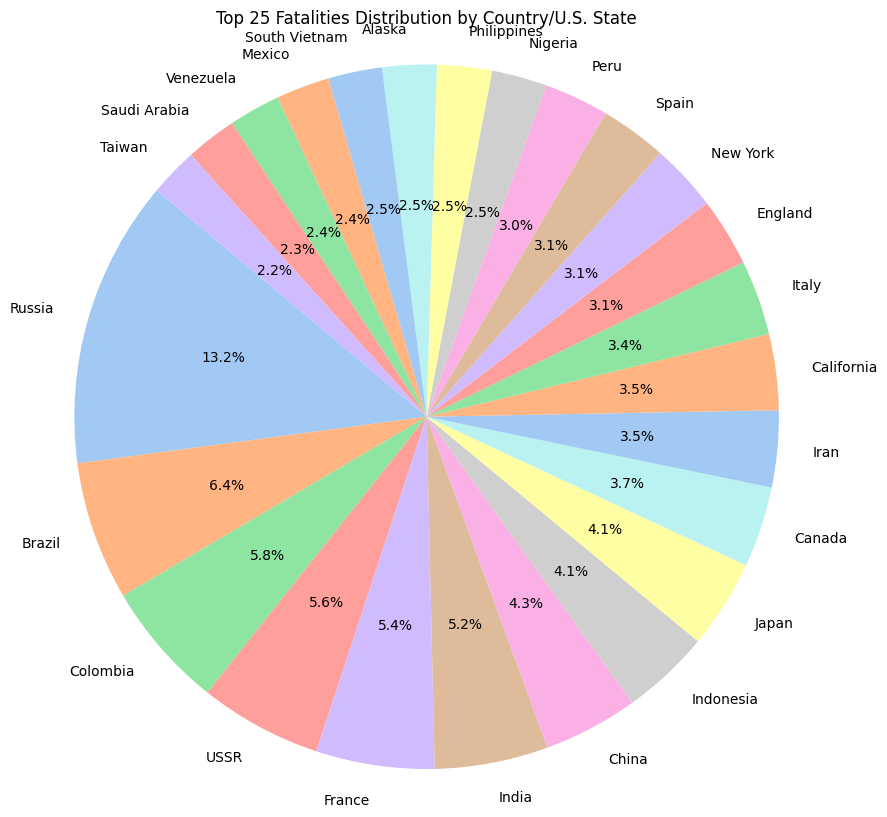

In [ ]:
# Group by country/state and get total fatalities, then select top 25
top_25_locations = (
    fatality_locations.groupby('State_Country')['Fatalities']
    .sum()
    .nlargest(25)
)

# Plotting using matplotlib/seaborn styling
plt.figure(figsize=(10, 10))
colors = sns.color_palette('pastel')[0:25]

plt.pie(
    top_25_locations,
    labels=top_25_locations.index,
    colors=colors,
    autopct='%.1f%%',
    startangle=140
)
plt.title('Top 25 Fatalities Distribution by Country/U.S. State')
plt.axis('equal')
plt.show()